# 07 — Sharpened Pipeline: Variance Filter + Random Forest

Keep top 20K variance genes, replace LR with RF.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from trace_path.config import Config
from trace_path.data import load_cache, variance_filter
from trace_path.labels import discover_tissue_category_pairs
from trace_path.models import make_rf_model
from trace_path.utils import run_all_tissue_models_parallel
from trace_path.evaluation import (
    plot_roc_grid, plot_pr_grid, plot_cm_grid, plot_boxplot_grid,
)

Config.ensure_dirs()

# Load cached data (run notebook 01 first)
X_wb, blood_subjid, _, df_meta_url, _ = load_cache()

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/TRACE/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


## Variance Filter — Top 20K Genes

In [2]:
X_wb_var, gene_var = variance_filter(X_wb)
print(f"Filtered: {X_wb.shape[1]:,} → {X_wb_var.shape[1]:,} genes")
print(f"Variance cutoff (rank {Config.N_TOP_VAR_GENES:,}): {gene_var.iloc[Config.N_TOP_VAR_GENES - 1]:.4f}")

Filtered: 59,033 → 20,000 genes
Variance cutoff (rank 20,000): 0.0765


## Run RF Models (Parallelized by Tissue)

In [3]:
pairs_df = discover_tissue_category_pairs(df_meta_url)

rf_results, rf_summary = run_all_tissue_models_parallel(
    pairs_df, df_meta_url, blood_subjid, X_wb_var, make_rf_model,
    save_features=True
)
rf_summary.to_csv(Config.TABLES_DIR / "cv_results_all_tissue_rf.csv", index=False)
print(f"Completed {len(rf_results)} RF models")
display(rf_summary)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  2.9min


[Parallel(n_jobs=-1)]: Done   8 out of  20 | elapsed: 15.1min remaining: 22.6min


[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed: 18.1min remaining: 14.8min


[Parallel(n_jobs=-1)]: Done  14 out of  20 | elapsed: 18.5min remaining:  7.9min


[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed: 20.6min remaining:  3.6min


Completed 59 RF models


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed: 26.0min finished


,tissue,category,mean_auc,std_auc,optimal_threshold
21,Breast - Mammary Tissue,atrophy,0.873447,0.087437,0.256
19,Breast - Mammary Tissue,gynecomastoid,0.827695,0.035680,0.320
35,Liver,cirrhosis,0.794853,0.082792,0.304
49,Pancreas,saponification,0.791520,0.050785,0.530
53,Spleen,congestion,0.779186,0.024508,0.738
20,Breast - Mammary Tissue,hyperplasia,0.755298,0.024906,0.348
42,Lung,pneumonia,0.736001,0.067445,0.252
45,Muscle - Skeletal,atrophy,0.718125,0.084476,0.718
52,Small Intestine - Terminal Ileum,nodularity,0.703965,0.050417,0.476
40,Lung,edema,0.672465,0.069180,0.324


## RF Evaluation Plots

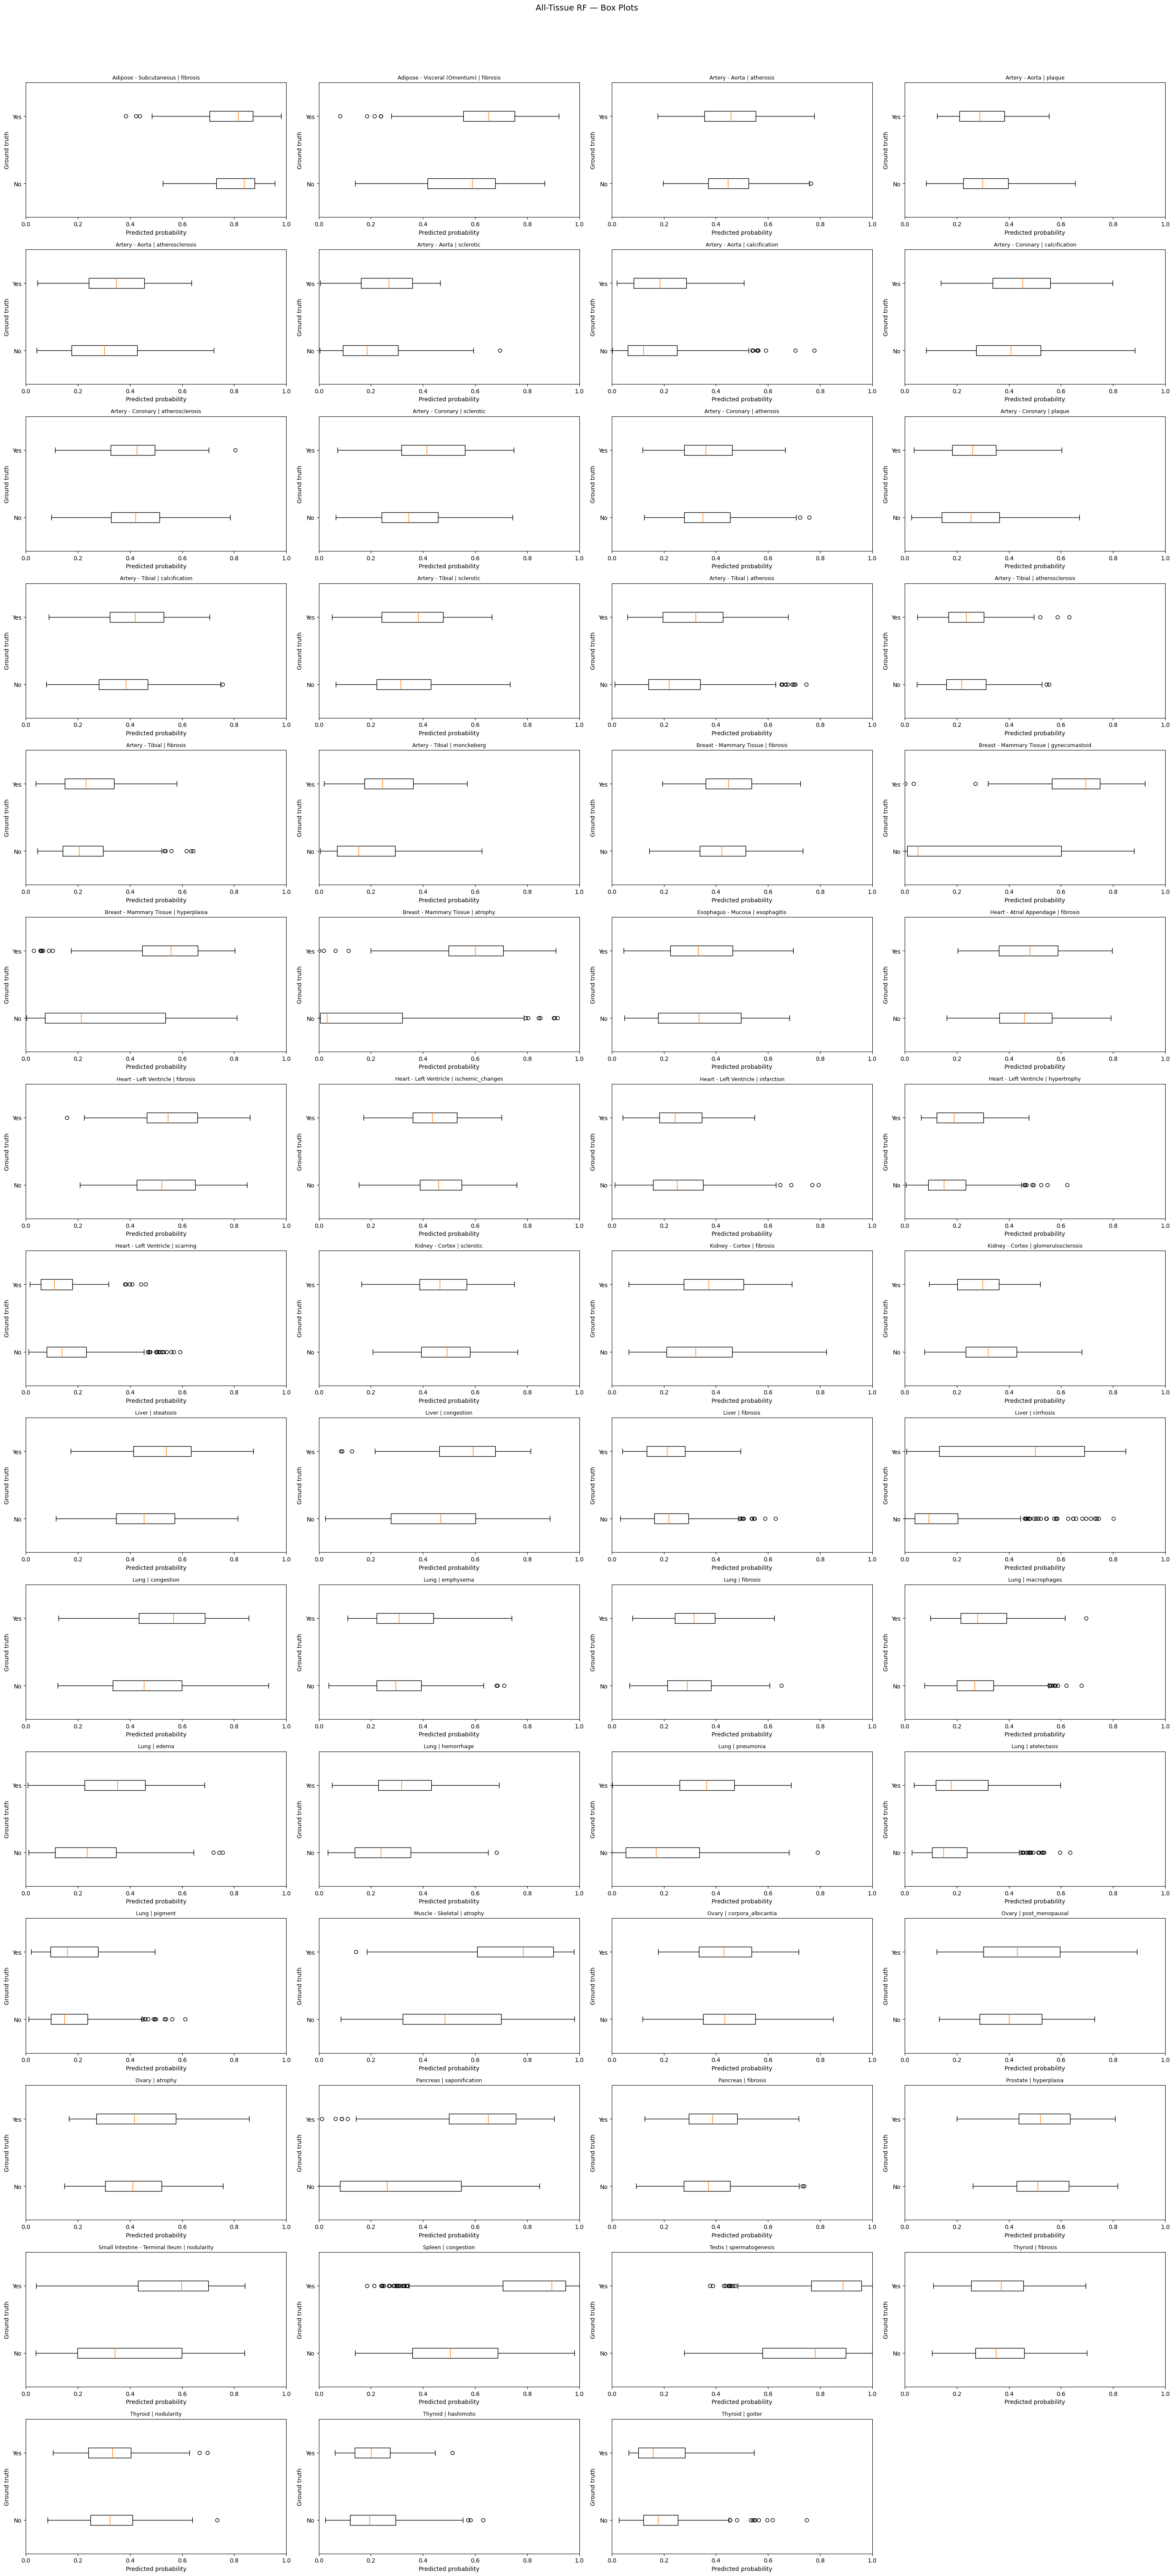

In [4]:
plot_roc_grid(rf_results,
             suptitle="All-Tissue RF — ROC (20K var-filtered)",
             save_path=Config.FIGURES_DIR / "roc_all_tissue_rf.pdf")
plot_boxplot_grid(rf_results,
                  suptitle="All-Tissue RF — Box Plots",
                  save_path=Config.FIGURES_DIR / "boxplot_all_tissue_rf.pdf")

## Feature Importances — Per-Fold & Aggregated

Extract per-fold selected genes and RF Gini importances from every model.

In [ ]:
rows_detail = []
for tag, res in rf_results.items():
    if "feature_info" not in res:
        continue
    for fi in res["feature_info"]:
        for gene in fi["selected_genes"]:
            rows_detail.append({
                "tissue": res["tissue"],
                "category": res["category"],
                "fold": fi["fold"],
                "gene": gene,
                "rf_importance": fi["rf_importances"].get(gene, 0.0),
            })

df_detail = pd.DataFrame(rows_detail)
df_detail.to_csv(Config.TABLES_DIR / "rf_selected_features.csv", index=False)
print(f"Per-fold detail: {len(df_detail):,} rows "
      f"({df_detail[['tissue','category']].drop_duplicates().shape[0]} models × 5 folds × {Config.TOP_K_FEATURES} genes)")

df_agg = (
    df_detail.groupby(["tissue", "category", "gene"])
    .agg(
        mean_importance=("rf_importance", "mean"),
        std_importance=("rf_importance", "std"),
        n_folds_selected=("fold", "nunique"),
    )
    .reset_index()
    .sort_values(["tissue", "category", "mean_importance"], ascending=[True, True, False])
)
df_agg.to_csv(Config.TABLES_DIR / "rf_feature_importances.csv", index=False)
print(f"Aggregated: {len(df_agg):,} unique (tissue, category, gene) entries")
print(f"\nConsensus genes (≥3/5 folds) per model:")
consensus = df_agg[df_agg["n_folds_selected"] >= 3]
print(consensus.groupby(["tissue", "category"]).size().describe())
display(df_agg.head(20))